# Working with Mobile Robots

This notebook introduces the workflow for robots mounted on mobile platforms in RobotBlockSet. Its purpose is to show how to create, configure, simulate, and control combined mobile-manipulator systems through a unified interface.


## What this notebook covers

The examples below demonstrate the main steps for working with a robot arm attached to a mobile base, including initialization, state capture, coordinated motion, and analysis of robot and platform behavior during execution.

Use this notebook as a practical reference when you want to understand how RobotBlockSet represents mobile manipulators and how to adapt the workflow to your own robot-platform setup.


# Imports


In [ ]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import time
from datetime import datetime

from robotblockset.tools import get_rbs_path
from robotblockset.platform_utils import check_panda_reach

from robotblockset.mujoco.robots_pymujoco import mujoco_scene, panda
from robotblockset.mujoco.platforms_pymujoco import tiagobase

np.set_printoptions(formatter={"float": "{: 0.4f}".format})

## Motion Capture

Mobile manipulators combine a robot arm and a mobile base, so it is useful to capture both subsystems during coordinated motion. As in `tutorial_robots.ipynb` and `tutorial_platforms.ipynb`, we first define callbacks that store the actual and commanded states during updates.

The first callback is attached to the robot and reads the platform through `r.Platform`. The second callback is attached to the platform and reads the robot through `p.Robot`. Either direction works once the two objects are linked with `SetBasePlatform`.


In [3]:
ir = 0
def CaptureP_R(r):
    global ir, trun, tt, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, Ft, mt, xtw, vtw, rxtw, rvtw, pxt, ptht, pvt, prxt, prvt, pmt, puxt, rTbt
    p = r.Platform
    if ir == 0:
        tt = np.array(r.t)
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        Ft = r._actual.FT
        mt = r._command.mode
        xtw = r.x
        vtw = r.GetVel(task_space="World", state="Actual")
        rxtw = r._command.rx
        rvtw = r.GetVel(task_space="World", state="Commanded")
        pxt = p._actual.x
        ptht = p.theta
        pvt = p._actual.v
        prxt = p._command.x
        prvt = p._command.v
        puxt = p._command.ux
        pmt = p._command.mode
        rTbt = r.GetBasePose(out="x")
    else:
        tt = np.vstack((tt, r.t))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        Ft = np.vstack((Ft, r._actual.FT))
        mt = np.vstack((mt, r._command.mode))
        xtw = np.vstack((xtw, r.x))
        vtw = np.vstack((vtw, r.GetVel(task_space="World", state="Actual")))
        rxtw = np.vstack((rxtw, r._command.rx))
        rvtw = np.vstack((rvtw, r.GetVel(task_space="World", state="Commanded")))
        pxt = np.vstack((pxt, p._actual.x))
        ptht = np.vstack((ptht, p.theta))
        pvt = np.vstack((pvt, p._actual.v))
        prxt = np.vstack((prxt, p._command.x))
        prvt = np.vstack((prvt, p._command.v))
        puxt = np.vstack((puxt, p._command.ux))
        pmt = np.vstack((pmt, p._command.mode))
        rTbt = np.vstack((rTbt, r.GetBasePose(out="x")))

    ir += 1

In [4]:
# Callback for Update
ip = 0
def CaptureR_P(p):
    global ip, trun, tt, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, Ft, mt, xtw, vtw, rxtw, rvtw, pxt, ptht, pvt, prxt, prvt, pmt, puxt, rTbt
    r = p.Robot
    if ip == 0:
        tt = np.array(r.t)
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        Ft = r._actual.FT
        mt = r._command.mode
        xtw = r.x
        vtw = r.GetVel(task_space="World", state="Actual")
        rxtw = r._command.rx
        rvtw = r.GetVel(task_space="World", state="Commanded")
        pxt = p._actual.x
        ptht = p.theta
        pvt = p._actual.v
        prxt = p._command.x
        prvt = p._command.v
        puxt = p._command.ux
        pmt = p._command.mode
        rTbt = r.GetBasePose(out="x")
    else:
        tt = np.vstack((tt, r.t))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        Ft = np.vstack((Ft, r._actual.FT))
        mt = np.vstack((mt, r._command.mode))
        xtw = np.vstack((xtw, r.x))
        vtw = np.vstack((vtw, r.GetVel(task_space="World", state="Actual")))
        rxtw = np.vstack((rxtw, r._command.rx))
        rvtw = np.vstack((rvtw, r.GetVel(task_space="World", state="Commanded")))
        pxt = np.vstack((pxt, p._actual.x))
        ptht = np.vstack((ptht, p.theta))
        pvt = np.vstack((pvt, p._actual.v))
        prxt = np.vstack((prxt, p._command.x))
        prvt = np.vstack((prvt, p._command.v))
        puxt = np.vstack((puxt, p._command.ux))
        pmt = np.vstack((pmt, p._command.mode))
        rTbt = np.vstack((rTbt, r.GetBasePose(out="x")))

    ip += 1

# Mobile Manipulator Objects

A mobile manipulator in RBS is modeled as a robot mounted on a mobile platform. The robot keeps its full joint-space and task-space interface from `robots.py`, while the base keeps its planar motion interface from `platforms.py`.

The key point is that after attachment the robot base pose is no longer treated as fixed in the world. Instead, it is updated from the platform state, so robot task-space quantities such as `r.x` are expressed in the moving world configuration of the whole system.


# Creation Of A Mobile Manipulator Object

The backend depends on the target system. In this tutorial we use a MuJoCo scene that already contains a Tiago base, a Panda arm, and a box to grasp.

After creating the robot and platform objects, we connect them using `r.SetBasePlatform(b)`. This is the mobile-manipulator equivalent of defining the robot base location in `tutorial_robots.ipynb` and the attached robot in `tutorial_platforms.ipynb`.


In [5]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/tiagobase_panda_box_scene.xml"
scene = mujoco_scene(MODEL_PATH, show_camera=None, synchronized=True, verbose=1)

r = panda(scene=scene)  # host="178.172.42.230")
r._verbose = 2
b = tiagobase(scene=scene)
b._verbose = 2
r.SetBasePlatform(b)

[RBS_INFO] [10:33:22] [panda_PyMuJoCo]: Robot connected to MuJoCo
[RBS_INFO] [10:33:23] [tiagobase_PyMuJoCo]: Platform connected to MuJoCo


## Initialisation And Default Parameters

Before running coordinated motion, we set the initial joint configuration, synchronize the robot and platform sampling times, and adjust several default controller parameters.

We change the default DampedPseudoInverseFactor to prevent oscillations when the robot moves toward singular configutrtion. 

The capture callbacks are then registered on both subsystems so the later motion can be analysed.


In [6]:
r.SetTsamp(0.01)
b.SetTsamp(0.01)
r._default.DampedPseudoInverseFactor = 0.1
r.SetCaptureCallback(CaptureP_R)
b.SetCaptureCallback(CaptureR_P)

## Preparing The Mobile Manipulator

A typical workflow is to first place the platform, then move the arm into a convenient joint configuration, and finally manipulate the object.

The next cells therefore: move the base to a known planar pose with `CMoveToLocation`, move the arm with `JMove`, place the box with `SetMocapPose`, move the tool to the box pose with `CMove`, and activate the MuJoCo equality constraint that represents the grasp.


In [7]:
b.CMoveToLocation([0, 0], rtheta=0, asynchronous=True)

[RBS_DEBUG] [10:33:23] [tiagobase_PyMuJoCo]: ASYNC CMoveToLocation


<Thread(Thread-6 (_CMoveToLocation), started daemon 69444)>

In [8]:
q_init = [0, -0.3, 0, -2.3,  0,  2.,  0.7776]
r.JMove(q_init, 2)

[RBS_DEBUG] [10:33:23] [panda_PyMuJoCo]: JMove started to: [ 0.0000 -0.3000  0.0000 -2.3000  0.0000  2.0000  0.7776] in 2.0s
[RBS_DEBUG] [10:33:23] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [10:33:23] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.000
[RBS_DEBUG] [10:33:23] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [10:33:23] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [10:33:28] [panda_PyMuJoCo]: JMove finished


0

# Robot used to position the platform


In this example the robot is commanded to hold its current end-effector pose with a long `CMove`, while the platform executes `CMoveToLocation` in the object frame. 

The robot fixes its end-effector location by grasping the object. Note that in this example, the robot is used as a sensor for the platform, i.e. the location of the platform can be determined very precisely in object frame.

In simulator we place the object to the desired location.

In [9]:
r.SetMocapPose("Box",[0.5, 0.0, 0.6])

Instead of grasping the object in MuJoCo simulator, we connected end-effector to the object.

In [10]:
r.CMove(r.GetObjectPose("site", "Box"))
r.SetEquality("Grasp_box",True)

[RBS_DEBUG] [10:33:28] [panda_PyMuJoCo]: CMove started: [ 0.5000  0.0000  0.6000  0.0000 -1.0000 -0.0000 -0.0000] with velocity 100.0%
[RBS_DEBUG] [10:33:28] [panda_PyMuJoCo]: Execution time will be prolonged due to bounded task velocities form 1.0s to 0.5s.
[RBS_DEBUG] [10:33:30] [panda_PyMuJoCo]: CMove finished


After the grasp is established, `r.EEFixed = True` tells the mobile-manipulator model that the end-effector is constrained to the external object. This is important during subsequent base motion because the arm controller must respect that the tool pose is no longer free.


In [11]:
r.EEFixed = True


For combined motion, it is good practice to first align commanded and actual states using `ResetCurrentTarget` on both the platform and the robot. This avoids discontinuities when the next asynchronous commands start.

 The platform command uses `robot_as_a_sensor=True` and `reach_check_fn=check_Panda_reach`, which means the base controller continuously checks whether the arm can still reach the task while the base is moving.

Capture is enabled before the motion so both the planar base states and the robot world-frame task states can be plotted afterwards.


In [12]:
b.ResetCurrentTarget()
r.ResetCurrentTarget()
b.ResetTime()
ip = 0
r.ResetTime()
ir = 0

x0 = r.x_ref
b.StartCapture()
th = r.CMove(x0, 100, asynchronous=True)
th1 = b.CMoveToLocation([-.65, -0.0],0.0, allow_backward=True, task_space="Object", robot_as_a_sensor=True, reach_check_fn=check_panda_reach, d_min=0.01, final_orientation_correction=False, pos_err=0.01,vel_fac=0.1)
b.Wait(1)
r.Abort()
b.StopCapture()

[RBS_DEBUG] [10:33:30] [panda_PyMuJoCo]: ASYNC CMove
[RBS_DEBUG] [10:33:30] [panda_PyMuJoCo]: CMove started: [ 5.00591177e-01 -9.02935139e-05  5.99667819e-01  4.63817283e-04
 -9.99988476e-01 -9.69805451e-04  4.67881013e-03] in World space in 100.0s
[RBS_DEBUG] [10:33:45] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [10:33:45] [tiagobase_PyMuJoCo]: Wait for 1 s
[RBS_DEBUG] [10:33:47] [panda_PyMuJoCo]: Abort: True


We compare actual and commanded trajectories for both subsystems. The plots show the platform position and heading together with the robot end-effector position in world coordinates and the selected angular velocity component.

This is the standard pattern for analysing mobile-manipulator behaviour in RBS: capture during motion, then inspect how the base and arm references evolved together.


[RBS_WARN] [1774344827.256387472] [panda_PyMuJoCo]: Motion aborted by user
[RBS_DEBUG] [10:33:47] [panda_PyMuJoCo]: CMove finished


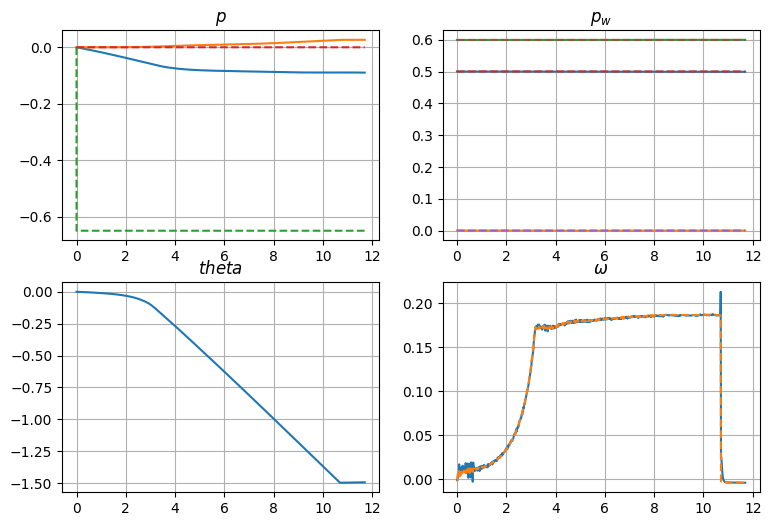

In [13]:

fig, ax = plt.subplots(2, 2, num=1, figsize=(9, 6))
ax[0, 0].plot(tt, pxt[:, :2])
ax[0, 0].plot(tt, prxt[:, :2], "--")
ax[0, 0].grid()
ax[0, 0].set_title("$p$")

ax[1, 0].plot(tt, ptht)
#ax[1, 0].plot(tt, rvt[:, :2], "--")
#ax[1, 0].plot(tt, ut[:, 0], ":")
ax[1, 0].grid()
ax[1, 0].set_title("$theta$")

ax[0, 1].plot(tt, xtw[:, :3])
ax[0, 1].plot(tt, rxtw[:, :3], "--")
ax[0, 1].grid()
ax[0, 1].set_title("$p_w$")

ax[1, 1].plot(tt, vt[:, 5])
ax[1, 1].plot(tt, rvt[:, 5], "--")
#ax[1, 1].plot(tt[:it], ut[:it, 1], ":")
ax[1, 1].grid()
ax[1, 1].set_title("$\\omega$")

plt.show()

# Coordinated motion

This second example compares two situations for the same Cartesian goal. First the arm tries to reach the target while the platform stays fixed. Then the same target is executed again while the base is allowed to move, which increases the overall workspace of the mobile manipulator.


In [14]:
r.Restart()
r.ResetCurrentTarget()
b.ResetCurrentTarget()

The first step is to restart the robot controller and reset the commanded targets of both subsystems. This gives a clean starting point before comparing the two reachability cases.


In [15]:
q_init = [0, -0.3, 0, -2.3,  0,  2.,  0.7776]
r._default.TaskDOF=np.array([1, 1, 1, 1, 1, 1])
r._default.DampedPseudoInverseFactor = 0.1
r._default.TaskContSpace = "World"
r._default.Traj="trap"
b.CMoveToLocation([0, 0], rtheta=0)
r.JMove(q_init)
r.ResetCurrentTarget()

[RBS_DEBUG] [10:33:48] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [10:33:48] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.000
[RBS_DEBUG] [10:33:48] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [10:33:48] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [10:33:48] [panda_PyMuJoCo]: JMove started: [ 0.0000 -0.3000  0.0000 -2.3000  0.0000  2.0000  0.7776] with velocity 100.0%
[RBS_DEBUG] [10:33:48] [panda_PyMuJoCo]: Execution time will be prolonged due to bounded joint velocities form 1.0s to 1.1s.
[RBS_DEBUG] [10:33:49] [panda_PyMuJoCo]: JMove finished


0

Next we set the controller defaults, move the platform to a known pose, and send the arm to the initial joint configuration. As in the robot tutorial, `TaskContSpace = "World"` means the Cartesian target will be interpreted in the world frame.


In [16]:
x0 = r.x_ref
x1 = x0.copy()
x1[:3] += [1, -0.5, 0]
print("Initial robot pose:", x0)
print("Final   robot pose:", x1)


Initial robot pose: [ 0.5662 -0.0000  0.6905 -0.0001 -0.9998 -0.0214  0.0047]
Final   robot pose: [ 1.5662 -0.5000  0.6905 -0.0001 -0.9998 -0.0214  0.0047]


Here `x0` is the current robot reference pose and `x1` is a displaced target pose. The translation `[1, -0.5, 0]` is chosen so that the goal is outside the arm-only workspace when the mobile base does not move.


## Arm-Only Attempt

In the first case the platform remains fixed, so only the manipulator tries to execute the Cartesian motion. This demonstrates that a target can be valid in world coordinates but still unreachable for the arm when the base pose is unchanged.


In [51]:
r.ResetTime()
b.ResetTime()
ir = 0
ip = 0

r.StartCapture()
th_p = r.CMove(x1, 10, asynchronous=False)
r.StopCapture()

[RBS_DEBUG] [11:08:05] [panda_PyMuJoCo]: Capture started
[RBS_DEBUG] [11:08:05] [panda_PyMuJoCo]: CMove started: [ 1.5662 -0.5000  0.6905  0.0001  0.9998  0.0214 -0.0047] in World space in 10.0s
[RBS_WARN] [1774346905.586073160] [panda_PyMuJoCo]: No close solution found in 1001 iterations, err: [ 0.6879 -0.2344  0.1399  0.0419  0.1219 -0.0015]
[RBS_DEBUG] [11:08:25] [panda_PyMuJoCo]: CMove finished
[RBS_DEBUG] [11:08:25] [panda_PyMuJoCo]: Capture stopped


We reset time, clear the capture indices, start logging, and run `r.CMove(x1, 10)` without moving the platform. The capture callback stores both actual and commanded world-frame trajectories so the tracking error can be inspected afterwards.


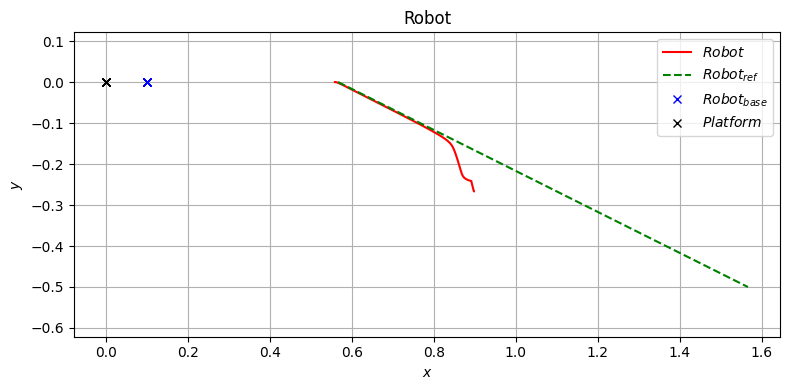

In [20]:
fig, ax = plt.subplots(1, 1, num=1, figsize=(8, 4))
ax = np.array(ax).flatten()
ax[0].plot(xtw[:,0],xtw[:,1], "r-", label="$Robot$")
ax[0].plot(rxtw[:,0],rxtw[:,1], "g--", label="$Robot_{ref}$")
ax[0].plot(rTbt[:,0],rTbt[:,1], "bx", label="$Robot_{base}$")
ax[0].plot(pxt[:,0],pxt[:,1], "kx", label="$Platform$")
ax[0].grid()
ax[0].axis("equal")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
ax[0].set_title("Robot")
ax[0].legend()

plt.tight_layout()


The plot shows the actual end-effector path, the commanded reference path, the robot base pose, and the platform pose. Because the platform does not move, the end-effector trajectory stops short of the requested Cartesian target.


## Coordinated Base-And-Arm Motion

We now repeat the same Cartesian task, but this time the platform is allowed to move while the arm follows the target. The mobile base shifts the robot base frame so the final end-effector pose becomes reachable.


In [52]:
r.Restart()
r.ResetCurrentTarget()
b.ResetCurrentTarget()
b.CMoveToLocation([0, 0], rtheta=0)
r.JMove(q_init)
r.ResetCurrentTarget()

[RBS_DEBUG] [11:08:37] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [11:08:37] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.000
[RBS_DEBUG] [11:08:37] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [11:08:37] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [11:08:37] [panda_PyMuJoCo]: JMove started: [ 0.0000 -0.3000  0.0000 -2.3000  0.0000  2.0000  0.7776] with velocity 100.0%
[RBS_DEBUG] [11:08:37] [panda_PyMuJoCo]: Execution time will be prolonged due to bounded joint velocities form 1.0s to 1.1s.
[RBS_DEBUG] [11:08:39] [panda_PyMuJoCo]: JMove finished


0

Before the coordinated run we again restart the system, bring the platform to the nominal start pose, move the arm to `q_init`, and reset the current robot target. This ensures the second trial starts from the same configuration as the first one.


In [53]:
r.ResetTime()
b.ResetTime()
ir = 0
ip = 0

r.StartCapture()
th_b = b.CMoveToLocation([1.1, -0.6], rtheta=np.pi/4, asynchronous=True)
th_p = r.CMove(x1, 10, asynchronous=False)
while th_b.is_alive():
     r.Update()
r.StopCapture()

[RBS_DEBUG] [11:08:42] [panda_PyMuJoCo]: Capture started
[RBS_DEBUG] [11:08:42] [tiagobase_PyMuJoCo]: ASYNC CMoveToLocation
[RBS_DEBUG] [11:08:42] [panda_PyMuJoCo]: CMove started: [ 1.5662 -0.5000  0.6905  0.0001  0.9998  0.0214 -0.0047] in World space in 10.0s
[RBS_DEBUG] [11:09:00] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [11:09:00] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.785
[RBS_DEBUG] [11:09:00] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [11:09:00] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [11:09:04] [panda_PyMuJoCo]: CMove finished
[RBS_DEBUG] [11:09:04] [panda_PyMuJoCo]: Capture stopped


During the coordinated run the platform command is launched asynchronously with `b.CMoveToLocation(...)`, while the robot executes `r.CMove(x1, 10)` in the world frame. The `while th_b.is_alive(): r.Update()` loop keeps the robot states and capture callback updated until the platform thread finishes.


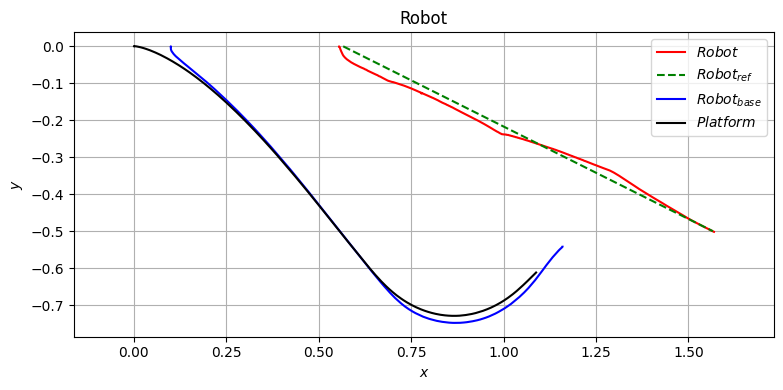

In [35]:
fig, ax = plt.subplots(1, 1, num=1, figsize=(8, 4))
ax = np.array(ax).flatten()
ax[0].plot(xtw[:,0],xtw[:,1], "r-", label="$Robot$")
ax[0].plot(rxtw[:,0],rxtw[:,1], "g--", label="$Robot_{ref}$")
ax[0].plot(rTbt[:,0],rTbt[:,1], "b-", label="$Robot_{base}$")
ax[0].plot(pxt[:,0],pxt[:,1], "k-", label="$Platform$")
ax[0].grid()
ax[0].axis("equal")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
ax[0].set_title("Robot")
ax[0].legend()

plt.tight_layout()


Comparing this plot with the previous one shows the benefit of the mobile manipulator formulation: the platform trajectory changes the robot-base path, and the arm can now follow the world-frame reference much more closely.


# Autonomous platform motion

This example uses the autonomous vector-field controller. In contrast to the previous examples, the platform is no longer commanded by a single target pose. Instead, it continuously generates local linear and angular velocity commands from the current manipulator configuration.

In [54]:
r.Restart()
r.ResetCurrentTarget()
b.ResetCurrentTarget()
b.CMoveToLocation([0, 0], rtheta=0)
r.JMove(q_init)
r.ResetCurrentTarget()

[RBS_DEBUG] [11:09:11] [tiagobase_PyMuJoCo]: CMoveToLocation -> CMoveToOri
[RBS_DEBUG] [11:09:11] [tiagobase_PyMuJoCo]: CMoveToOri started: theta=0.000
[RBS_DEBUG] [11:09:11] [tiagobase_PyMuJoCo]: CMoveToOri finished
[RBS_DEBUG] [11:09:11] [tiagobase_PyMuJoCo]: CMoveToLocation finished
[RBS_DEBUG] [11:09:11] [panda_PyMuJoCo]: JMove started: [ 0.0000 -0.3000  0.0000 -2.3000  0.0000  2.0000  0.7776] with velocity 100.0%
[RBS_DEBUG] [11:09:11] [panda_PyMuJoCo]: Execution time will be prolonged due to bounded joint velocities form 1.0s to 1.1s.
[RBS_DEBUG] [11:09:13] [panda_PyMuJoCo]: JMove finished


0

As before, we first restart the system, bring the platform to a known planar pose, move the Panda arm to `q_init`, and reset the robot target. This gives the autonomous base controller a clean initial configuration before the end-effector starts moving toward `x1`.


In [55]:
from robotblockset.platform_utils import track_panda_vf
r.ResetTime()
b.ResetTime()
ir = 0
ip = 0

r.StartCapture()
b.AutonomousMotion(callback=track_panda_vf, platform=b, a_max=0.25, alpha=0.25, f_zone=0.12, b_zone=0.1)
r.CMove(x1, 10)
r.CMove(x1, 2)
b.AbortAutonomousMotion()
r.StopCapture()


[RBS_DEBUG] [11:09:39] [panda_PyMuJoCo]: Capture started
[RBS_DEBUG] [11:09:39] [tiagobase_PyMuJoCo]: ASYNC AutonmousMotion
[RBS_DEBUG] [11:09:39] [tiagobase_PyMuJoCo]: AutonmousMotion started
[RBS_DEBUG] [11:09:39] [panda_PyMuJoCo]: CMove started: [ 1.5662 -0.5000  0.6905  0.0001  0.9998  0.0214 -0.0047] in World space in 10.0s
[RBS_DEBUG] [11:09:58] [panda_PyMuJoCo]: CMove finished
[RBS_DEBUG] [11:09:58] [panda_PyMuJoCo]: CMove started: [ 1.5662 -0.5000  0.6905  0.0001  0.9998  0.0214 -0.0047] in World space in 2.0s
[RBS_DEBUG] [11:10:03] [panda_PyMuJoCo]: CMove finished
[RBS_DEBUG] [11:10:03] [panda_PyMuJoCo]: Capture stopped


[RBS_DEBUG] [11:10:03] [tiagobase_PyMuJoCo]: AutonmousMotion finished


## Local Vector-Field Controller

`track_panda_vf` runs as the callback of `b.AutonomousMotion(...)`. The controller uses a reduced 5-DoF Panda kinematic model and only the translational TCP position relative to the robot base, so the base behavior is fully local and does not depend on global localization.

The logic follows the zone-based description from `auto_platform.tex`:

- when the TCP is comfortably inside the workspace, the platform holds position,
- when the TCP approaches the outer workspace boundary, the platform drives forward,
- when the TCP gets too close to the base, the platform enters retreat mode and moves backward while reorienting.

The arguments in this example define the main autonomous-motion parameters: `a_max` limits linear acceleration, `alpha` sets exponential smoothing of the commanded velocities, `f_zone` is the forward-activation threshold near the outer reach boundary, and `b_zone` is the retreat threshold near the inner safety zone.

The autonomous controller is started first, then the robot performs two `CMove` commands toward the same Cartesian goal. During these motions the platform thread keeps updating `Set_vel([v, omega])` from the current TCP position. Finally, `b.AbortAutonomousMotion()` stops the autonomous thread and `r.StopCapture()` ends logging.


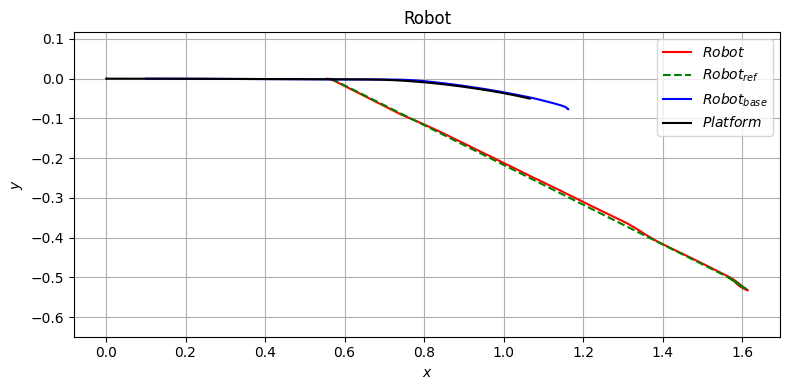

In [49]:
fig, ax = plt.subplots(1, 1, num=1, figsize=(8, 4))
ax = np.array(ax).flatten()
ax[0].plot(xtw[:,0],xtw[:,1], "r-", label="$Robot$")
ax[0].plot(rxtw[:,0],rxtw[:,1], "g--", label="$Robot_{ref}$")
ax[0].plot(rTbt[:,0],rTbt[:,1], "b-", label="$Robot_{base}$")
ax[0].plot(pxt[:,0],pxt[:,1], "k-", label="$Platform$")
ax[0].grid()
ax[0].axis("equal")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
ax[0].set_title("Robot")
ax[0].legend()

plt.tight_layout()


The resulting plot can be compared with the previous coordinated-motion examples. Here the platform trajectory is not generated from one planned base goal, but from the reactive velocity field. The curves therefore show how the autonomous controller keeps the robot base in a favorable region of the workspace while the arm tracks the Cartesian command.
